# Étape 1 — Analyse exploratoire (EDA)

Dataset : `data/patients_nutrition.csv` — suivi nutritionnel de patients (données synthétiques).

Objectif de l'étape : décrire la structure des données, les distributions, le taux de
valeurs manquantes par colonne, et vérifier la cohérence interne (`bmi` fourni vs IMC
recalculé) afin de cadrer le nettoyage de l'étape 2.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/patients_nutrition.csv")
df.shape


(2500, 15)

## 1. Structure et intégrité

In [2]:
df.head()

,patient_id,age,gender,height_cm,weight_kg,bmi,diet_type,condition,admission_date,daily_calories,daily_protein_g,daily_sodium_mg,follow_up_weeks,weight_change_pct,nutritionist_visits
0,PAT-00001,65,Femme,176.4,60.0,19.3,Hyperprotéiné,Hypertension,2025-12-27,1992.0,NaN,2433.0,21,-4.17,10
1,PAT-00002,43,Homme,162.4,60.9,23.1,Hyperprotéiné,Diabète type 2,2025-09-28,1288.0,46.5,3370.0,24,3.20,1
2,PAT-00003,41,Femme,177.6,77.6,24.6,Standard,Diabète type 2,2025-06-13,2068.0,49.5,2269.0,17,2.30,2
3,PAT-00004,75,Homme,165.5,64.4,23.5,Diabétique,Insuffisance rénale,2025-06-03,1102.0,20.7,2294.0,7,1.98,2
4,PAT-00005,32,Femme,165.6,59.1,21.6,Diabétique,Insuffisance rénale,2025-11-20,2275.0,74.0,2109.0,2,-4.33,3


In [3]:
df.dtypes

patient_id                 str
age                      int64
gender                     str
height_cm              float64
weight_kg              float64
bmi                    float64
diet_type                  str
condition                  str
admission_date             str
daily_calories         float64
daily_protein_g        float64
daily_sodium_mg        float64
follow_up_weeks          int64
weight_change_pct      float64
nutritionist_visits      int64
dtype: object

In [4]:
print("Lignes, colonnes :", df.shape)
print("patient_id uniques :", df["patient_id"].nunique(), "/", len(df))
print("patient_id dupliqués :", int(df["patient_id"].duplicated().sum()))
print("Lignes entièrement dupliquées :", int(df.duplicated().sum()))


Lignes, colonnes : (2500, 15)
patient_id uniques : 2500 / 2500
patient_id dupliqués : 0
Lignes entièrement dupliquées : 0


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,2500,2500,PAT-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2500.0,NaN,NaN,NaN,50.79,19.535203,18.0,34.0,51.0,67.0,84.0
gender,2500,2,Homme,1286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,2500.0,NaN,NaN,NaN,167.717,8.87884,145.0,162.1,167.7,173.6,200.0
weight_kg,2500.0,NaN,NaN,NaN,67.471,9.338851,40.0,61.4,67.5,74.0,100.3
bmi,2500.0,NaN,NaN,NaN,24.00208,2.983285,15.0,22.0,23.9,25.9,36.6
diet_type,2500,5,Standard,887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,2475,5,Aucune,973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_date,2500,539,2025-07-12,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_calories,2500.0,NaN,NaN,NaN,1803.1228,345.051601,900.0,1573.75,1804.0,2045.0,2978.0


## 2. Valeurs manquantes par colonne

`condition = "Aucune"` est une modalité valide (absence de pathologie), pas un null :
les deux sont comptés séparément ci-dessous.


In [6]:
missing = pd.DataFrame({
    "n_null": df.isna().sum(),
    "pct_null": (df.isna().mean() * 100).round(2),
})
missing = missing.sort_values("pct_null", ascending=False)
missing


,n_null,pct_null
weight_change_pct,225,9.0
daily_sodium_mg,150,6.0
daily_protein_g,100,4.0
condition,25,1.0
patient_id,0,0.0
age,0,0.0
gender,0,0.0
diet_type,0,0.0
bmi,0,0.0
weight_kg,0,0.0


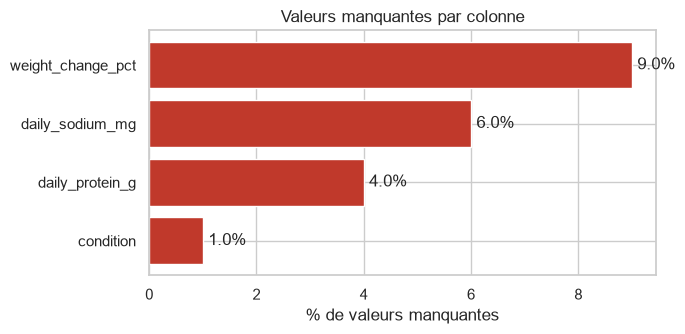

In [7]:
cols_with_null = missing[missing["n_null"] > 0].index.tolist()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(cols_with_null, missing.loc[cols_with_null, "pct_null"], color="#c0392b")
ax.invert_yaxis()
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes par colonne")
for i, c in enumerate(cols_with_null):
    ax.text(missing.loc[c, "pct_null"] + 0.1, i, f'{missing.loc[c, "pct_null"]:.1f}%', va="center")
plt.tight_layout()
plt.show()


In [8]:
rows_any_null = df.isna().any(axis=1).sum()
rows_multi_null = (df.isna().sum(axis=1) >= 2).sum()
print(f"Lignes avec >=1 valeur manquante : {rows_any_null} ({rows_any_null / len(df):.1%})")
print(f"Lignes avec >=2 valeurs manquantes : {rows_multi_null}")
print()
print("condition : 'Aucune' vs réellement manquante")
print(df["condition"].value_counts(dropna=False))
print()
print("diet_type des lignes où condition est manquante :")
print(df.loc[df["condition"].isna(), "diet_type"].value_counts())


Lignes avec >=1 valeur manquante : 465 (18.6%)
Lignes avec >=2 valeurs manquantes : 33

condition : 'Aucune' vs réellement manquante
condition
Aucune                 973
Diabète type 2         538
Hypertension           449
Obésité                348
Insuffisance rénale    167
NaN                     25
Name: count, dtype: int64

diet_type des lignes où condition est manquante :
diet_type
Standard         9
Diabétique       7
Hypocalorique    3
Hyperprotéiné    3
Sans sel         3
Name: count, dtype: int64


## 3. Distributions des variables numériques

In [9]:
num_cols = [
    "age", "height_cm", "weight_kg", "bmi",
    "daily_calories", "daily_protein_g", "daily_sodium_mg",
    "follow_up_weeks", "weight_change_pct", "nutritionist_visits",
]
df[num_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T


,count,mean,std,min,1%,25%,50%,75%,99%,max
age,2500.0,50.790000,19.535203,18.00,18.000,34.000,51.00,67.00,84.000,84.00
height_cm,2500.0,167.717000,8.878840,145.00,145.599,162.100,167.70,173.60,187.909,200.00
weight_kg,2500.0,67.471000,9.338851,40.00,45.100,61.400,67.50,74.00,88.201,100.30
bmi,2500.0,24.002080,2.983285,15.00,17.100,22.000,23.90,25.90,31.301,36.60
daily_calories,2500.0,1803.122800,345.051601,900.00,1013.930,1573.750,1804.00,2045.00,2579.000,2978.00
daily_protein_g,2400.0,65.559250,19.888826,-0.20,17.299,52.675,65.40,78.60,112.801,128.70
daily_sodium_mg,2350.0,2808.781702,910.200625,-142.00,714.290,2204.750,2818.50,3421.00,4949.100,6405.00
follow_up_weeks,2500.0,12.996400,7.217564,1.00,1.000,7.000,13.00,19.00,25.000,25.00
weight_change_pct,2275.0,-0.499477,3.102031,-11.98,-7.940,-2.485,-0.49,1.48,6.550,11.89
nutritionist_visits,2500.0,2.515200,1.556258,0.00,0.000,1.000,2.00,3.00,7.000,10.00


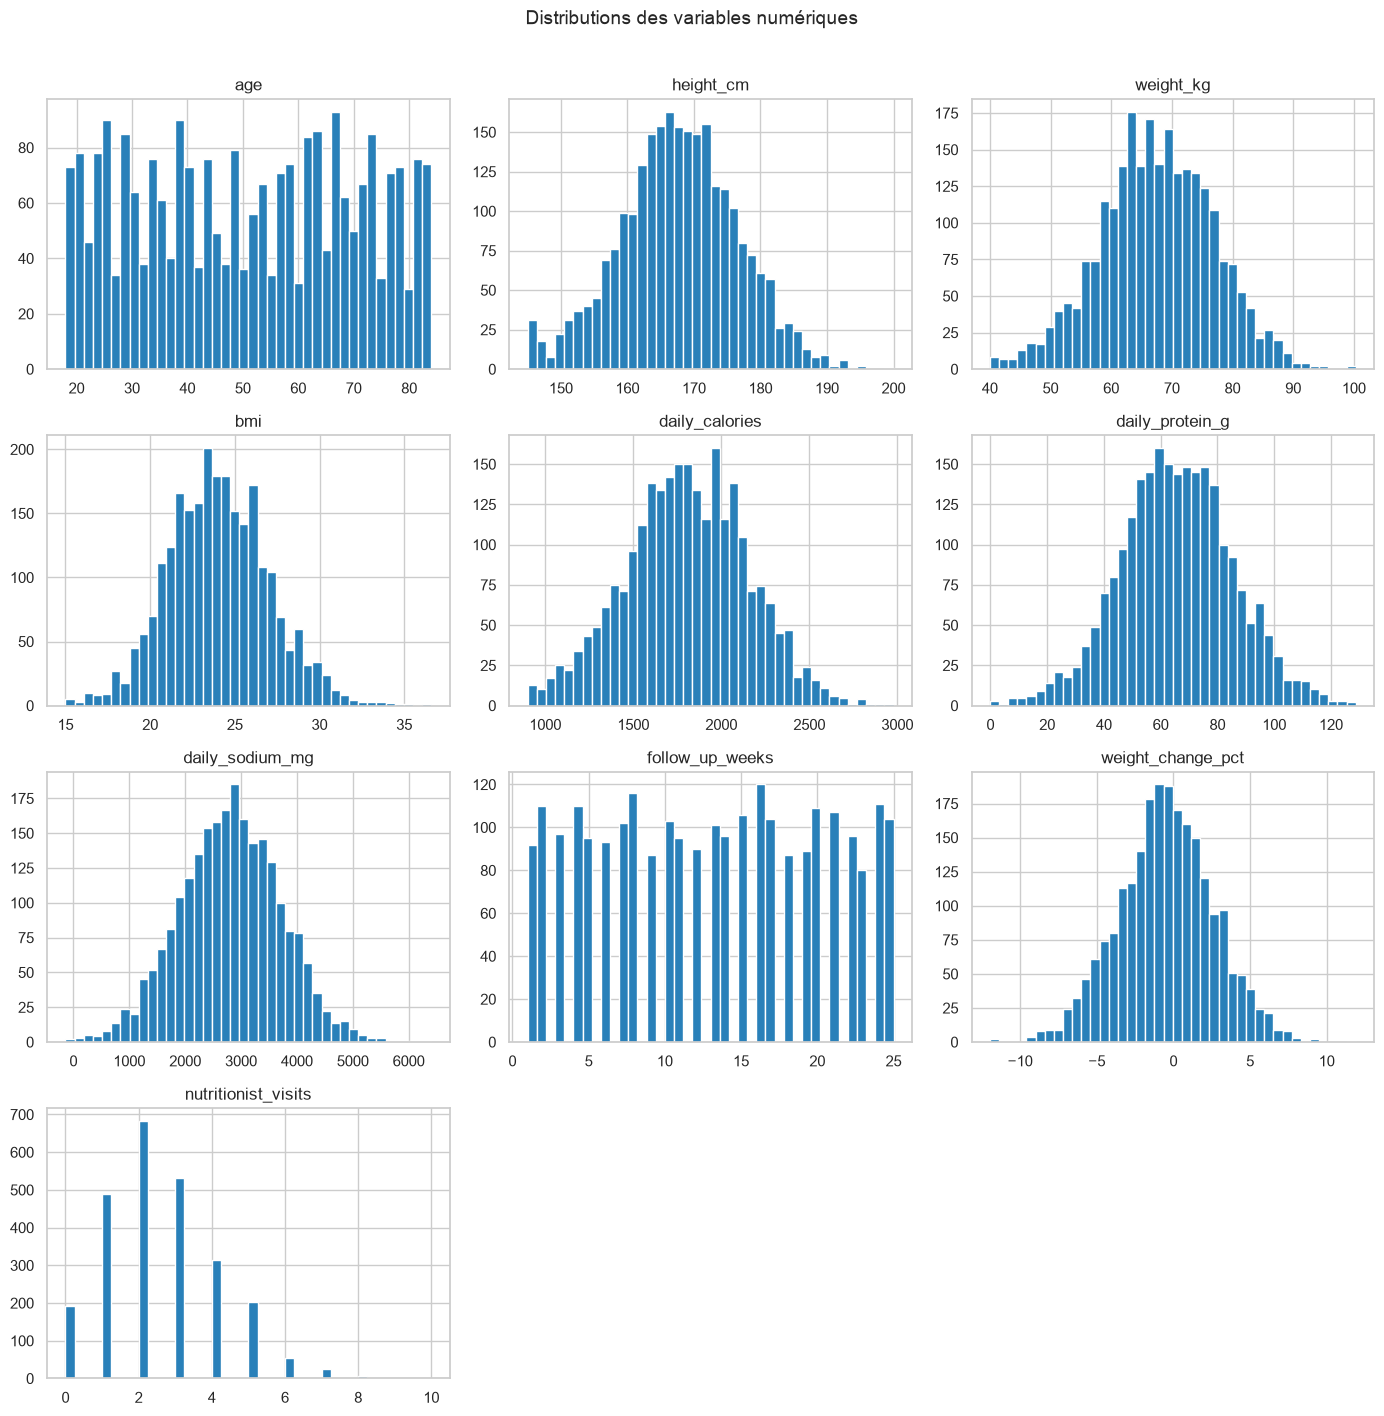

In [10]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(df[col].dropna(), bins=40, color="#2980b9", edgecolor="white")
    ax.set_title(col)
for ax in axes.ravel()[len(num_cols):]:
    ax.set_visible(False)
fig.suptitle("Distributions des variables numériques", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


## 4. Distributions des variables catégorielles

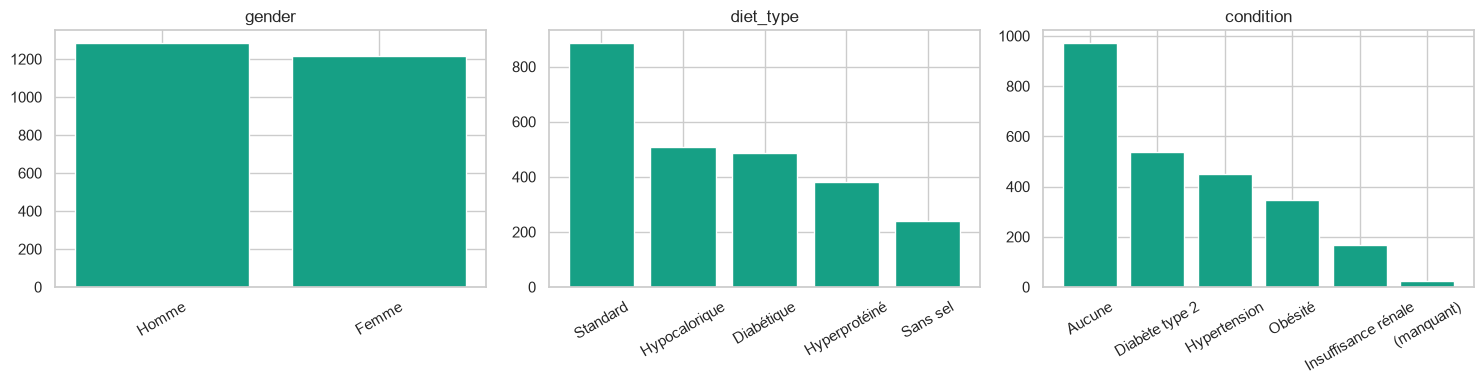

--- gender ---
gender
Homme    1286
Femme    1214
Name: count, dtype: int64

--- diet_type ---
diet_type
Standard         887
Hypocalorique    507
Diabétique       486
Hyperprotéiné    380
Sans sel         240
Name: count, dtype: int64

--- condition ---
condition
Aucune                 973
Diabète type 2         538
Hypertension           449
Obésité                348
Insuffisance rénale    167
NaN                     25
Name: count, dtype: int64



In [11]:
cat_cols = ["gender", "diet_type", "condition"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_cols):
    vc = df[col].astype("string").fillna("(manquant)").value_counts()
    ax.bar(vc.index.tolist(), vc.values, color="#16a085")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()


## 5. Couverture temporelle (`admission_date`)

Min : 2025-01-01  Max : 2026-06-29  Étendue : 544 jours
Dates dans le futur (> 2026-09-07) : 0


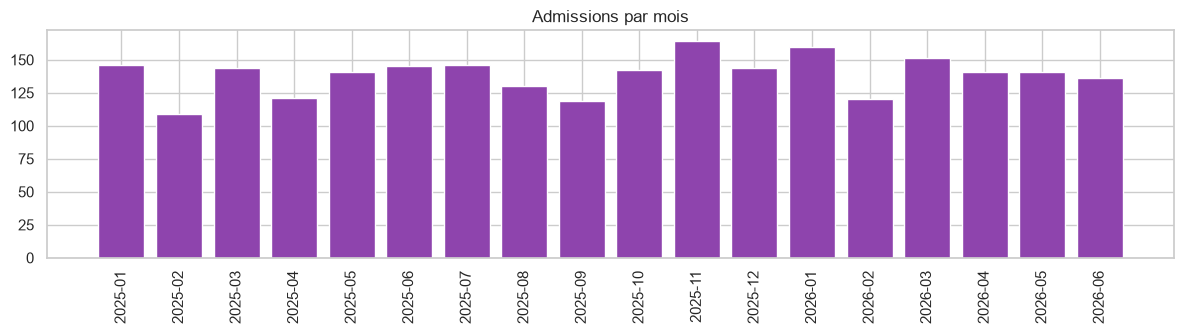

In [12]:
adm = pd.to_datetime(df["admission_date"])
print("Min :", adm.min().date(), " Max :", adm.max().date(), " Étendue :", (adm.max() - adm.min()).days, "jours")
print("Dates dans le futur (> 2026-09-07) :", int((adm > pd.Timestamp("2026-09-07")).sum()))

by_month = adm.dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(by_month.index.astype(str), by_month.values, color="#8e44ad")
ax.set_title("Admissions par mois")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


## 6. Cohérence `bmi` fourni vs IMC recalculé

IMC recalculé = `weight_kg / (height_cm / 100) ** 2`. La colonne `bmi` est fournie avec
une décimale : un écart absolu <= 0,05 correspond à la tolérance d'arrondi. Au-delà, il
faudrait suspecter une incohérence interne à traiter au nettoyage.


In [13]:
bmi_calc = df["weight_kg"] / (df["height_cm"] / 100) ** 2
diff = (df["bmi"] - bmi_calc).abs()
comparable = df["bmi"].notna() & df["height_cm"].notna() & df["weight_kg"].notna()

print("Lignes comparables :", int(comparable.sum()), "/", len(df))
print(diff[comparable].describe())
print()
for thr in (0.05, 0.1, 0.5, 1.0, 2.0):
    print(f"  |écart| > {thr:>4} : {int((diff[comparable] > thr).sum())}")


Lignes comparables : 2500 / 2500
count    2500.000000
mean        0.024515
std         0.014440
min         0.000003
25%         0.011853
50%         0.024326
75%         0.036959
max         0.050000
dtype: float64

  |écart| > 0.05 : 1
  |écart| >  0.1 : 0
  |écart| >  0.5 : 0
  |écart| >  1.0 : 0
  |écart| >  2.0 : 0


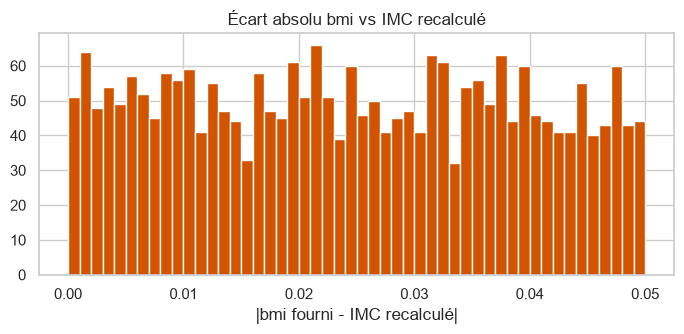

,patient_id,height_cm,weight_kg,bmi,bmi_calc,ecart
1111,PAT-01112,200.0,85.0,21.2,21.25,-0.05
1582,PAT-01583,162.9,74.7,28.2,28.15,0.05
1840,PAT-01841,168.7,58.2,20.4,20.45,-0.05
2182,PAT-02183,165.5,59.3,21.7,21.65,0.05
99,PAT-00100,178.1,74.7,23.6,23.55,0.05
233,PAT-00234,172.4,69.4,23.3,23.35,-0.05
2211,PAT-02212,170.3,74.1,25.5,25.55,-0.05
2473,PAT-02474,170.3,74.1,25.5,25.55,-0.05
2499,PAT-02500,177.1,77.0,24.6,24.55,0.05
1001,PAT-01002,162.6,65.7,24.8,24.85,-0.05


In [14]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(diff[comparable], bins=50, color="#d35400", edgecolor="white")
ax.set_xlabel("|bmi fourni - IMC recalculé|")
ax.set_title("Écart absolu bmi vs IMC recalculé")
plt.tight_layout()
plt.show()

df.assign(bmi_calc=bmi_calc.round(2), ecart=(df["bmi"] - bmi_calc).round(3))   .loc[comparable, ["patient_id", "height_cm", "weight_kg", "bmi", "bmi_calc", "ecart"]]   .reindex(diff[comparable].sort_values(ascending=False).index)   .head(10)


## 7. Valeurs hors plage plausible

Repérage (sans correction ici — la correction relève de l'étape 2) des valeurs
physiologiquement impossibles ou extrêmes.


In [15]:
checks = {
    "age < 18": (df["age"] < 18).sum(),
    "age > 90": (df["age"] > 90).sum(),
    "bmi < 15": (df["bmi"] < 15).sum(),
    "bmi > 40": (df["bmi"] > 40).sum(),
    "daily_calories < 800": (df["daily_calories"] < 800).sum(),
    "daily_calories > 3500": (df["daily_calories"] > 3500).sum(),
    "daily_protein_g <= 0": (df["daily_protein_g"] <= 0).sum(),
    "daily_protein_g < 5": (df["daily_protein_g"] < 5).sum(),
    "daily_sodium_mg < 0": (df["daily_sodium_mg"] < 0).sum(),
    "daily_sodium_mg < 100": (df["daily_sodium_mg"] < 100).sum(),
    "daily_sodium_mg > 5000": (df["daily_sodium_mg"] > 5000).sum(),
}
pd.Series(checks, name="n_lignes").to_frame()


,n_lignes
age < 18,0
age > 90,0
bmi < 15,0
bmi > 40,0
daily_calories < 800,0
daily_calories > 3500,0
daily_protein_g <= 0,1
daily_protein_g < 5,4
daily_sodium_mg < 0,2
daily_sodium_mg < 100,4


In [16]:
print("Protéines <= 5 g/j :")
print(df.loc[df["daily_protein_g"] < 5, ["patient_id", "diet_type", "daily_calories", "daily_protein_g"]])
print()
print("Sodium < 100 mg/j :")
print(df.loc[df["daily_sodium_mg"] < 100, ["patient_id", "diet_type", "condition", "daily_sodium_mg"]])


Protéines <= 5 g/j :
     patient_id      diet_type  daily_calories  daily_protein_g
210   PAT-00211  Hypocalorique          2266.0              1.6
519   PAT-00520     Diabétique          1883.0             -0.2
640   PAT-00641  Hypocalorique          1864.0              4.3
1088  PAT-01089  Hypocalorique          1873.0              1.5

Sodium < 100 mg/j :
     patient_id      diet_type            condition  daily_sodium_mg
1439  PAT-01440       Standard       Diabète type 2           -142.0
1722  PAT-01723  Hypocalorique  Insuffisance rénale            -18.0
1774  PAT-01775  Hyperprotéiné               Aucune             71.0
1972  PAT-01973       Standard         Hypertension             94.0


## 8. Corrélations entre variables numériques

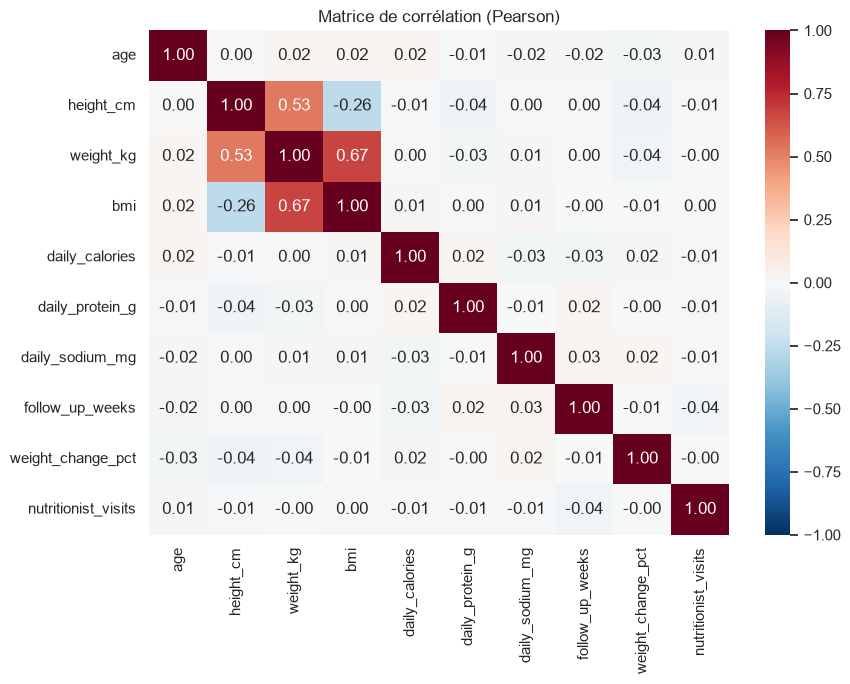

In [17]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matrice de corrélation (Pearson)")
plt.tight_layout()
plt.show()


## 9. Observations

- **Structure** : 2500 lignes, 15 colonnes, `patient_id` unique, aucune ligne dupliquée.
- **Valeurs manquantes** : 4 colonnes concernées — `weight_change_pct` (9 %),
  `daily_sodium_mg` (6 %), `daily_protein_g` (4 %), `condition` (1 %, 25 lignes,
  distinctes de la modalité `Aucune`). ~19 % des lignes ont au moins un null, mais les
  manques se recouvrent peu (33 lignes avec ≥ 2 nulls).
- **Distributions** : `age` bornée 18–84, `follow_up_weeks` 1–25, `bmi` centré ~24
  (15–36,6). Apports globalement plausibles ; `daily_sodium_mg` fortement étalé à droite.
- **Catégorielles** : genre ~équilibré ; `diet_type` dominé par `Standard` (35 %) ;
  `condition` : 39 % `Aucune`, puis Diabète type 2, Hypertension, Obésité, Insuffisance rénale.
- **Temporel** : admissions du 2025-01-01 au 2026-06-29 (≈ 18 mois), aucune date future.
- **Cohérence IMC** : écart absolu `bmi` vs IMC recalculé ≤ 0,05 sur les 2500 lignes
  (la seule « au-delà » est à 0,05000000000000071 — bruit de calcul flottant sur un
  0,05 exact). La colonne `bmi` est cohérente avec `height_cm`/`weight_kg` : pas de
  problème de qualité de ce côté, elle peut servir de contrôle croisé au nettoyage.
- **Valeurs aberrantes** : 1 protéine négative + 3 valeurs < 5 g/j ; 2 sodiums négatifs
  + 2 valeurs < 100 mg/j ; 20 sodiums > 5000 mg/j (queue haute, plausibilité limite).
  À traiter à l'étape 2.
- **Corrélations** : quasi nulles entre toutes les paires, en particulier
  `weight_change_pct` avec `follow_up_weeks`, `daily_calories`, `bmi`, `age`. Les
  variables d'évolution se comportent comme du bruit non relié aux profils.
